## Part 1 — Import Libraries and Plotting Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import norm, skew, kurtosis, jarque_bera, probplot, shapiro
from scipy.optimize import brentq

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# Clean academic plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries loaded and plotting style configured.")


Libraries loaded and plotting style configured.


## Part 2 — Load Both Datasets

Two real datasets are used:

1. **NIFTY 50 historical daily prices** (10-Sep-2025 to 10-Sep-2026) — used to build the return series and estimate historical volatility.
2. **NIFTY 50 European call option data** (31-Aug-2026, strike 24100) — used to obtain the actual market inputs (spot, strike, market price, expiry) for the Black–Scholes calculation.


In [2]:
# ---- Load NIFTY 50 historical data ----
nifty = pd.read_csv('NIFTY_50-10-09-2025-to-10-09-2026.csv')
nifty.columns = nifty.columns.str.strip()

# Strip whitespace from any string/object columns (this dataset has trailing spaces in values too)
for c in nifty.select_dtypes(include='object').columns:
    nifty[c] = nifty[c].astype(str).str.strip()

nifty['Date'] = pd.to_datetime(nifty['Date'], format='%d-%b-%Y')
nifty = nifty.sort_values('Date').reset_index(drop=True)

print("NIFTY 50 dataset shape:", nifty.shape)
print("\nColumn names:", nifty.columns.tolist())


NIFTY 50 dataset shape: (248, 7)

Column names: ['Date', 'Open', 'High', 'Low', 'Close', 'Shares Traded', 'Turnover (₹ Cr)']


/tmp/ipykernel_484/3626192806.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in nifty.select_dtypes(include='object').columns:


In [3]:
print("First 5 observations:")
nifty.head()


First 5 observations:


,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,2025-09-10,"24,991.0000","25,035.7000","24,915.0500","24,973.1000",244146466,"22,458.9800"
1,2025-09-11,"24,945.5000","25,037.3000","24,940.1500","25,005.5000",224570983,"21,316.7200"
2,2025-09-12,"25,074.4500","25,139.4500","25,038.0500","25,114.0000",225739766,"21,335.6700"
3,2025-09-15,"25,118.9000","25,138.4500","25,048.7500","25,069.2000",185375759,"17,115.6000"
4,2025-09-16,"25,073.6000","25,261.4000","25,070.4500","25,239.1000",240122320,"22,642.8600"


In [6]:
# ---- Load NIFTY option data ----
opt = pd.read_csv('OPTIDX_NIFTY_CE_31-Aug-2026_TO_31-Aug-2026__1_.csv')
opt.columns = opt.columns.str.strip()

for c in opt.select_dtypes(include='object').columns:
    opt[c] = opt[c].astype(str).str.strip()

opt['Date'] = pd.to_datetime(opt['Date'], format='%d-%b-%Y')
opt['Expiry'] = pd.to_datetime(opt['Expiry'], format='%d-%b-%Y')

print("Option dataset shape:", opt.shape)
print("\nColumn names:", opt.columns.tolist())
opt


Option dataset shape: (1, 17)

Column names: ['Symbol', 'Date', 'Expiry', 'Option type', 'Strike Price', 'Open', 'High', 'Low', 'Close', 'LTP', 'Settle Price', 'No. of contracts', 'Turnover * in  ₹ Lakhs', 'Premium Turnover ** in   ₹ Lakhs', 'Open Int', 'Change in OI', 'Underlying Value']


/tmp/ipykernel_484/2032965430.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in opt.select_dtypes(include='object').columns:


,Symbol,Date,Expiry,Option type,Strike Price,Open,High,Low,Close,LTP,Settle Price,No. of contracts,Turnover * in ₹ Lakhs,Premium Turnover ** in ₹ Lakhs,Open Int,Change in OI,Underlying Value
0,NIFTY,2026-08-31,2026-10-27,CE,"24,100.0000",520.0000,584.3000,493.5500,543.0000,539.0500,543.0000,811.0000,"12,983.9600",279.6400,"40,755.0000","3,380.0000","24,080.4000"


## Part 3 — Identify the Option Observation

We now programmatically extract the option row for Date = 31-Aug-2026, Option type = CE, Strike = 24100.


In [8]:
row = opt[(opt['Date'] == '2026-08-31') &
          (opt['Option type'] == 'CE') &
          (opt['Strike Price'].astype(float) == 24100.00)]

print("Selected option observation:")
row


Selected option observation:


,Symbol,Date,Expiry,Option type,Strike Price,Open,High,Low,Close,LTP,Settle Price,No. of contracts,Turnover * in ₹ Lakhs,Premium Turnover ** in ₹ Lakhs,Open Int,Change in OI,Underlying Value
0,NIFTY,2026-08-31,2026-10-27,CE,"24,100.0000",520.0000,584.3000,493.5500,543.0000,539.0500,543.0000,811.0000,"12,983.9600",279.6400,"40,755.0000","3,380.0000","24,080.4000"


In [9]:
assert len(row) == 1, "Expected exactly one matching option observation."
row = row.iloc[0]

S = float(row['Underlying Value'])
K = float(row['Strike Price'])
market_price = float(row['Close'])
option_date = row['Date']
expiry_date = row['Expiry']

print(f"S (underlying spot)     = {S}")
print(f"K (strike price)        = {K}")
print(f"C_market (market close) = {market_price}")
print(f"Option date             = {option_date.date()}")
print(f"Expiry date             = {expiry_date.date()}")


S (underlying spot)     = 24080.4
K (strike price)        = 24100.0
C_market (market close) = 543.0
Option date             = 2026-08-31
Expiry date             = 2026-10-27


In [10]:
params_table = pd.DataFrame({
    'Parameter': ['Underlying NIFTY spot', 'Strike price', 'Observed call price', 'Option date', 'Expiry date'],
    'Symbol': ['S', 'K', 'C_market', '', ''],
    'Value': [f'{S:,.2f}', f'{K:,.2f}', f'{market_price:,.2f}', str(option_date.date()), str(expiry_date.date())]
})
params_table


,Parameter,Symbol,Value
0,Underlying NIFTY spot,S,"24,080.40"
1,Strike price,K,"24,100.00"
2,Observed call price,C_market,543.00
3,Option date,,2026-08-31
4,Expiry date,,2026-10-27


**Interpretation:** The spot value (₹24,080.40) and the strike price (₹24,100.00) are only about 20 index points apart — a difference of roughly 0.08%. The option is therefore **approximately at-the-money**: the market is pricing a call whose strike sits almost exactly at the current underlying level, so its value is driven mainly by time value and volatility rather than by deep intrinsic value.


## Part 4 — NIFTY Price Time Series

**Graph 1: Historical NIFTY 50 Closing Price**


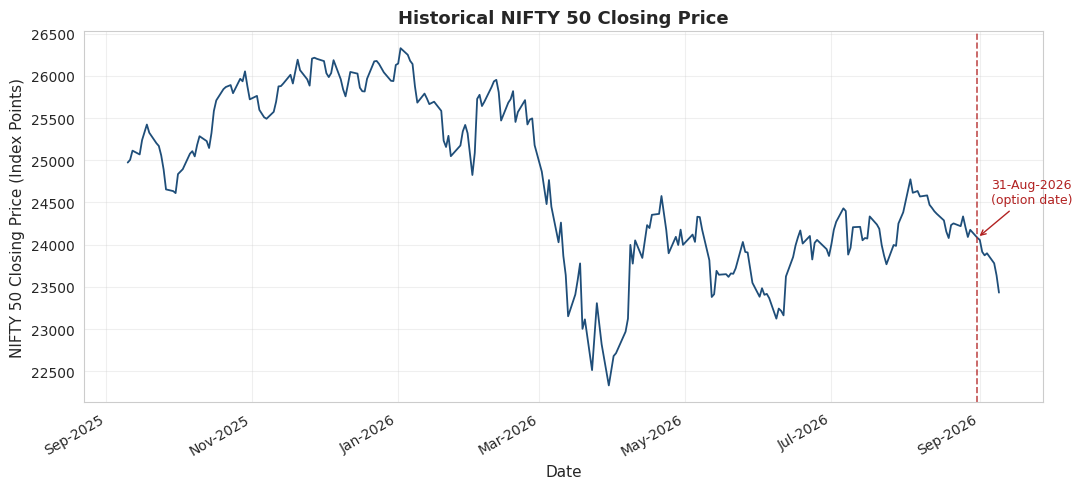

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(nifty['Date'], nifty['Close'], color='#1f4e79', linewidth=1.3)

ax.axvline(option_date, color='firebrick', linestyle='--', linewidth=1.2, alpha=0.8)
ax.annotate('31-Aug-2026\n(option date)', xy=(option_date, S),
            xytext=(10, 25), textcoords='offset points',
            fontsize=9, color='firebrick',
            arrowprops=dict(arrowstyle='->', color='firebrick', lw=1))

ax.set_title('Historical NIFTY 50 Closing Price')
ax.set_xlabel('Date')
ax.set_ylabel('NIFTY 50 Closing Price (Index Points)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
fig.autofmt_xdate()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


**Interpretation:** The plot shows the complete NIFTY 50 closing-price series across all 248 observations, with the option date (31-Aug-2026) marked for reference. The series shows the general upward-and-fluctuating path typical of an equity index. This graph is used purely to visualize the historical evolution of the underlying asset — **no claim of stationarity is made here**; visibly, the level of the series drifts over time, which is precisely why Black–Scholes is built on *returns* (or log-price increments) rather than on price levels directly.


## Part 5 — Compute Daily Log Returns

**Why log returns?** Log returns $r_t = \ln(S_t / S_{t-1})$ are used instead of simple returns because they are time-additive (the log return over several days is simply the sum of the daily log returns), they are the natural increment under the geometric Brownian motion model that underlies Black–Scholes, and they are approximately symmetric for small daily price changes. This makes them the natural statistical object for estimating volatility in the Black–Scholes framework.

**Restricting to the option date:** as noted above, only NIFTY observations up to and including 31-Aug-2026 are used for the historical volatility estimate — later dates in the file are not used for this calculation.


In [12]:
# Restrict to dates on/before the option date (no look-ahead)
nifty_hist = nifty[nifty['Date'] <= option_date].sort_values('Date').reset_index(drop=True)

nifty_hist['Log_Return'] = np.log(nifty_hist['Close'] / nifty_hist['Close'].shift(1))

n_prices = nifty_hist['Close'].shape[0]
returns = nifty_hist['Log_Return'].dropna()
n_returns = returns.shape[0]

print(f"Number of price observations (through {option_date.date()}): {n_prices}")
print(f"Number of daily log-return observations: {n_returns}")


Number of price observations (through 2026-08-31): 241
Number of daily log-return observations: 240


As expected, restricting the NIFTY sample to on-or-before the option date yields 241 price observations and 240 daily log returns — this is the return series that will be used throughout the rest of the analysis.


## Part 6 — Log-Return Time-Series Graph

**Graph 2: Daily NIFTY 50 Log Returns**


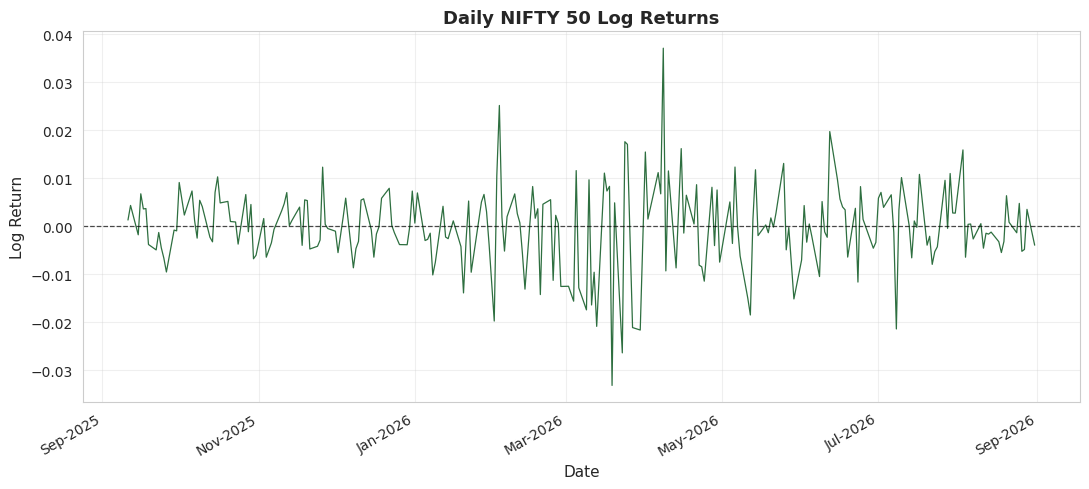

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_dates = nifty_hist['Date'].iloc[1:]
ax.plot(plot_dates, returns, color='#2e6f40', linewidth=0.9)
ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.7)

ax.set_title('Daily NIFTY 50 Log Returns')
ax.set_xlabel('Date')
ax.set_ylabel('Log Return')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
fig.autofmt_xdate()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


**Interpretation:** The daily log returns fluctuate around zero, consistent with the absence of a strong deterministic daily drift. The dispersion of the series around the zero line reflects volatility, and a small number of comparatively large positive or negative movements are visible against the background of smaller day-to-day fluctuations. It is exactly this dispersion that will be used, in Part 9, to estimate historical volatility for the Black–Scholes model.


## Part 7 — Histogram of Log Returns

**Graph 3: Distribution of Daily NIFTY 50 Log Returns**


In [14]:
mean_return = returns.mean()
std_return = returns.std(ddof=1)
median_return = returns.median()
min_return = returns.min()
max_return = returns.max()
skewness = skew(returns)
excess_kurt = kurtosis(returns, fisher=True)  # excess kurtosis (normal = 0)

stats_table = pd.DataFrame({
    'Statistic': ['Mean', 'Std. Deviation', 'Median', 'Minimum', 'Maximum', 'Skewness', 'Excess Kurtosis'],
    'Value': [mean_return, std_return, median_return, min_return, max_return, skewness, excess_kurt]
})
stats_table['Value'] = stats_table['Value'].map(lambda v: f'{v:.6f}')
stats_table


,Statistic,Value
0,Mean,-0.000152
1,Std. Deviation,0.008460
2,Median,0.000007
3,Minimum,-0.033165
4,Maximum,0.037088
5,Skewness,-0.145297
6,Excess Kurtosis,2.414331


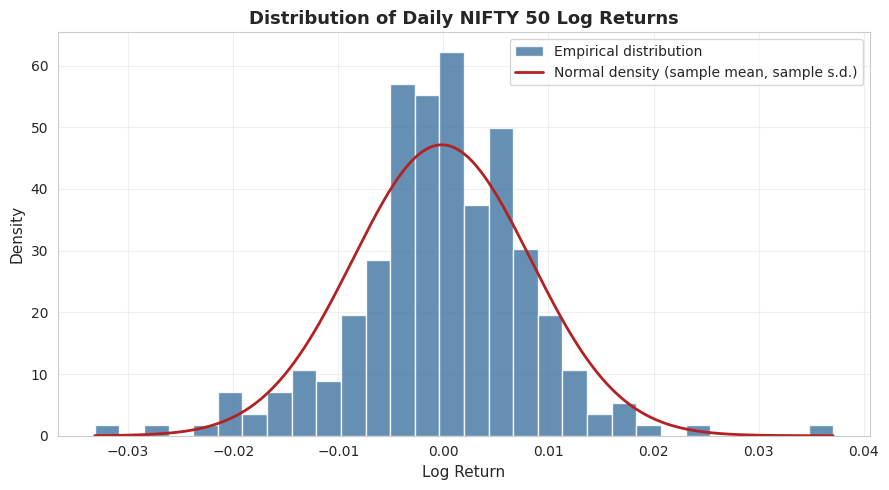

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
n_bins = 30
counts, bins, patches = ax.hist(returns, bins=n_bins, density=True, color='#4a7ba6',
                                 edgecolor='white', alpha=0.85, label='Empirical distribution')

x_grid = np.linspace(returns.min(), returns.max(), 300)
ax.plot(x_grid, norm.pdf(x_grid, mean_return, std_return), color='firebrick', linewidth=2,
        label='Normal density (sample mean, sample s.d.)')

ax.set_title('Distribution of Daily NIFTY 50 Log Returns')
ax.set_xlabel('Log Return')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


**Interpretation:** The empirical histogram is roughly bell-shaped and centred close to zero, broadly resembling the overlaid normal density built from the sample mean and standard deviation. However, the **excess kurtosis is positive**, which indicates heavier tails (more extreme observations) than a normal distribution would produce. This is directly relevant to Black–Scholes, whose basic derivation assumes that continuously compounded returns are normally distributed (equivalently, that prices follow a lognormal process). A positive excess kurtosis is a *departure* from this assumption, but it does **not by itself invalidate** the Black–Scholes framework — it simply means the normal-return assumption is an approximation, whose adequacy will be probed further with the Q–Q plot and a formal normality test below.


## Part 8 — Q–Q Plot and Normality Test

**Graph 4: Normal Q–Q Plot of NIFTY Log Returns**


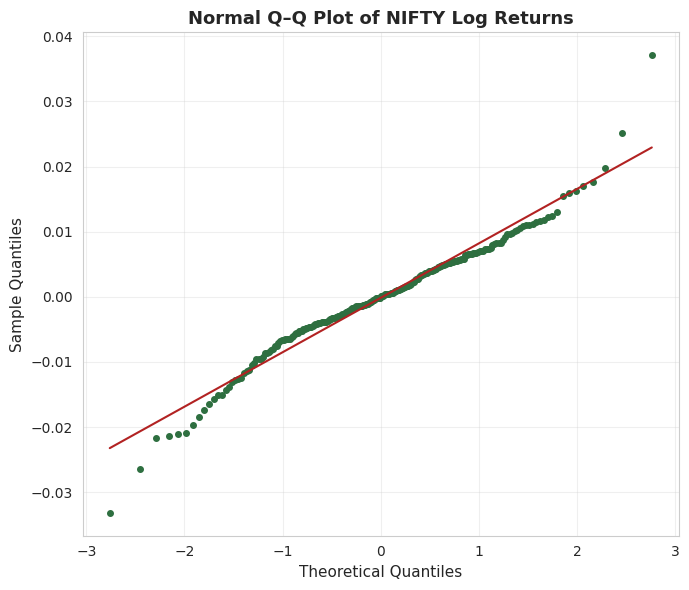

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
probplot(returns, dist='norm', plot=ax)
ax.set_title('Normal Q–Q Plot of NIFTY Log Returns')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.get_lines()[0].set_markerfacecolor('#2e6f40')
ax.get_lines()[0].set_markeredgecolor('#2e6f40')
ax.get_lines()[0].set_markersize(4)
ax.get_lines()[1].set_color('firebrick')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


**Interpretation:** Points lying close to the reference line indicate approximate agreement with normality over that range of quantiles; visible deviations — typically in the extreme tails — indicate departures from normality. This is a **visual diagnostic**, not a definitive proof either way; a formal test is used to complement it.


In [17]:
jb_stat, jb_pvalue = jarque_bera(returns)

print(f"Jarque–Bera statistic: {jb_stat:.4f}")
print(f"Jarque–Bera p-value:   {jb_pvalue:.6f}")

if jb_pvalue < 0.05:
    print("\nConclusion: normality is rejected at the 5% significance level.")
else:
    print("\nConclusion: there is insufficient evidence to reject normality at the 5% level.")


Jarque–Bera statistic: 59.1344
Jarque–Bera p-value:   0.000000

Conclusion: normality is rejected at the 5% significance level.


**Caution:** even where the test fails to reject normality, this should not be read as *proof* of normality — it only means the sample does not provide strong enough evidence against it. Where the test *does* reject normality, this is consistent with the heavier-than-normal tails already suggested by the positive excess kurtosis in Part 7.


## Part 9 — Historical Volatility Estimation

This is the key statistical step connecting the empirical return series to the Black–Scholes model. Volatility is **not directly observed** — it must be estimated statistically from the historical return series.

$$\sigma_{\text{annual}} = s_r \sqrt{252}$$

where $s_r$ is the sample standard deviation of daily log returns and 252 is the conventional number of trading days per year used for annualization.


In [18]:
sigma_daily = std_return  # sample standard deviation of daily log returns, computed above
trading_days = 252
annualization_factor = np.sqrt(trading_days)
sigma_annual = sigma_daily * annualization_factor

print(f"Daily volatility (sample std. dev. of log returns): {sigma_daily:.8f}")
print(f"Annualization factor (sqrt(252)):                   {annualization_factor:.6f}")
print(f"Annualized historical volatility:                    {sigma_annual:.8f}  ({sigma_annual*100:.4f}%)")


Daily volatility (sample std. dev. of log returns): 0.00845995
Annualization factor (sqrt(252)):                   15.874508
Annualized historical volatility:                    0.13429749  (13.4297%)


**Interpretation:** The daily standard deviation of log returns is scaled by $\sqrt{252}$ under the (standard, simplifying) assumption that daily log returns are independent and identically distributed, so that variance scales linearly with the number of trading days. This produces the annualized historical volatility, which will now serve as the volatility input $\sigma$ in the Black–Scholes formula. This is the central link between the statistical description of returns (Parts 5–8) and the option-pricing model.


## Part 10 — Rolling Volatility (Diagnostic Only)

**Graph 5: 60-Day Rolling Annualized Volatility of NIFTY 50**

This graph is diagnostic only — the Black–Scholes calculation itself uses the single full-sample annualized volatility from Part 9, not a rolling estimate.


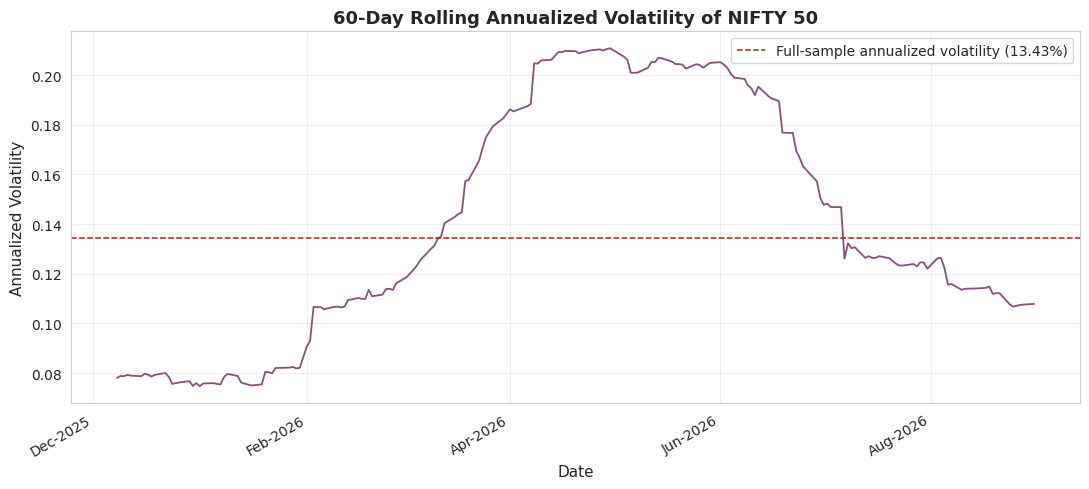

In [19]:
rolling_vol = nifty_hist['Log_Return'].rolling(60).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(nifty_hist['Date'], rolling_vol, color='#8a4f7d', linewidth=1.3)
ax.axhline(sigma_annual, color='firebrick', linestyle='--', linewidth=1.1,
           label=f'Full-sample annualized volatility ({sigma_annual*100:.2f}%)')

ax.set_title('60-Day Rolling Annualized Volatility of NIFTY 50')
ax.set_xlabel('Date')
ax.set_ylabel('Annualized Volatility')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
fig.autofmt_xdate()
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


**Interpretation:** Black–Scholes assumes **constant volatility** over the life of the option, whereas the rolling-window estimate shows that empirical volatility varies over time — rising and falling as market conditions change. This is a direct empirical illustration of one of the model's simplifying assumptions being only approximately satisfied in practice. The main Black–Scholes calculation below nonetheless uses the single full-sample annualized volatility from Part 9, consistent with the model's constant-volatility assumption.


## Part 11 — Black–Scholes Inputs

We now assemble the full set of Black–Scholes inputs, combining the **actual option-market data** (spot, strike, dates) with the **statistically estimated volatility** from Part 9.


In [20]:
T_days = (expiry_date - option_date).days
T = T_days / 365

r = 0.065   # ASSUMED illustrative continuously compounded risk-free rate (dataset provides no risk-free rate)
q = 0.0     # simplifying assumption: no dividend yield

sigma = sigma_annual

print(f"Time to expiry: {T_days} calendar days  ->  T = {T:.6f} years")
print(f"Risk-free rate (assumed): r = {r}")
print(f"Dividend yield (assumed): q = {q}")
print(f"Volatility (from historical estimation): sigma = {sigma:.6f}")


Time to expiry: 57 calendar days  ->  T = 0.156164 years
Risk-free rate (assumed): r = 0.065
Dividend yield (assumed): q = 0.0
Volatility (from historical estimation): sigma = 0.134297


In [21]:
inputs_table = pd.DataFrame({
    'Input': ['Spot price', 'Strike', 'Historical volatility', 'Risk-free rate', 'Dividend yield', 'Time to expiry'],
    'Symbol': ['S', 'K', 'sigma', 'r', 'q', 'T'],
    'Value': [f'{S:,.2f}', f'{K:,.2f}', f'{sigma*100:.2f}%', f'{r*100:.1f}%', f'{q*100:.0f}%', f'{T:.5f} yrs ({T_days} days)'],
    'Source / Assumption': ['Actual option dataset', 'Actual option dataset',
                             'Estimated from NIFTY returns (Part 9)',
                             'Assumed illustrative continuously-compounded rate',
                             'Simplifying assumption', 'Calculated from option/expiry dates']
})
inputs_table


,Input,Symbol,Value,Source / Assumption
0,Spot price,S,"24,080.40",Actual option dataset
1,Strike,K,"24,100.00",Actual option dataset
2,Historical volatility,sigma,13.43%,Estimated from NIFTY returns (Part 9)
3,Risk-free rate,r,6.5%,Assumed illustrative continuously-compounded rate
4,Dividend yield,q,0%,Simplifying assumption
5,Time to expiry,T,0.15616 yrs (57 days),Calculated from option/expiry dates


## Part 12 — The Black–Scholes Formula

The Black–Scholes price of a European call option is:

$$C = S\,e^{-qT}N(d_1) - K\,e^{-rT}N(d_2)$$

where

$$d_1 = \frac{\ln(S/K) + \left(r - q + \dfrac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

**In plain language:**
- $S$ is today's price of the underlying asset (the NIFTY 50 index level), and $K$ is the fixed strike price at which the call holder may buy it.
- $r$ and $q$ are the (continuously compounded) risk-free interest rate and dividend yield; they discount future cash flows and adjust the growth rate of the underlying under the model's risk-neutral assumption.
- $\sigma$ is the volatility parameter — the standard deviation of the underlying's continuously compounded returns — which is the quantity we estimated statistically in Part 9.
- $T$ is the time remaining to expiry, in years.
- $N(\cdot)$ is the cumulative distribution function of the standard normal distribution. $N(d_1)$ and $N(d_2)$ can loosely be read as (risk-neutral) probability-weighted terms governing, respectively, the expected benefit of holding the underlying and the expected cost of paying the strike.
- $d_1$ and $d_2$ combine all of the above into two standardized quantities from which the option's theoretical value is built.


## Part 13 — Calculate $d_1$ and $d_2$

In [22]:
d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

Nd1 = norm.cdf(d1)
Nd2 = norm.cdf(d2)

print(f"d1     = {d1:.6f}")
print(f"d2     = {d2:.6f}")
print(f"N(d1)  = {Nd1:.6f}")
print(f"N(d2)  = {Nd2:.6f}")


d1     = 0.202471
d2     = 0.149399
N(d1)  = 0.580226
N(d2)  = 0.559381


In [23]:
d_table = pd.DataFrame({
    'Quantity': ['d1', 'd2', 'N(d1)', 'N(d2)'],
    'Value': [f'{d1:.6f}', f'{d2:.6f}', f'{Nd1:.6f}', f'{Nd2:.6f}']
})
d_table


,Quantity,Value
0,d1,0.202471
1,d2,0.149399
2,N(d1),0.580226
3,N(d2),0.559381


## Part 14 — Manual-Style Numerical Substitution

Substituting the computed quantities into the Black–Scholes formula (with $q = 0$, so the $e^{-qT}$ discount term equals 1):

$$C = S\,N(d_1) - K\,e^{-rT}N(d_2)$$

$$C = 24080.40 \times N(d_1) \;-\; 24100 \times e^{-(0.065)(0.156164)} \times N(d_2)$$

The two terms are computed programmatically below (the numeric $d_1$, $d_2$ and $T$ values above are the *actual* computed values, not the placeholder figures quoted in the seminar plan).


In [24]:
term1 = S * Nd1
discount_factor = np.exp(-r * T)
term2 = K * discount_factor * Nd2

C_BS_manual = term1 - term2

print(f"Term 1: S * N(d1)             = {S:,.2f} * {Nd1:.5f} = {term1:,.4f}")
print(f"Discount factor exp(-rT)      = {discount_factor:.6f}")
print(f"Term 2: K * exp(-rT) * N(d2)  = {K:,.2f} * {discount_factor:.5f} * {Nd2:.5f} = {term2:,.4f}")
print(f"\nC_BS = Term 1 - Term 2 = {C_BS_manual:,.4f}")


Term 1: S * N(d1)             = 24,080.40 * 0.58023 = 13,972.0632
Discount factor exp(-rT)      = 0.989901
Term 2: K * exp(-rT) * N(d2)  = 24,100.00 * 0.98990 * 0.55938 = 13,344.9254

C_BS = Term 1 - Term 2 = 627.1377


## Part 15 — Final Black–Scholes Price vs Market Price

In [25]:
def bs_call_price(S, K, T, r, q, sigma):
    d1_ = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2_ = d1_ - sigma * np.sqrt(T)
    return S * np.exp(-q * T) * norm.cdf(d1_) - K * np.exp(-r * T) * norm.cdf(d2_)

C_BS = bs_call_price(S, K, T, r, q, sigma)

abs_diff = C_BS - market_price
pct_diff_vs_market = (C_BS - market_price) / market_price * 100
pct_diff_vs_model = (C_BS - market_price) / C_BS * 100

print(f"Black-Scholes theoretical price: {C_BS:,.4f}")
print(f"Observed market price:           {market_price:,.4f}")
print(f"Absolute difference:             {abs_diff:,.4f}")
print(f"Percentage difference (vs market): {pct_diff_vs_market:.4f}%")
print(f"Percentage difference (vs model):  {pct_diff_vs_model:.4f}%")


Black-Scholes theoretical price: 627.1377
Observed market price:           543.0000
Absolute difference:             84.1377
Percentage difference (vs market): 15.4950%
Percentage difference (vs model):  13.4162%


In [26]:
comparison_table = pd.DataFrame({
    'Measure': ['Observed market price', 'Black–Scholes price', 'Absolute difference', 'Percentage difference (vs market)'],
    'Value': [f'₹{market_price:,.2f}', f'₹{C_BS:,.2f}', f'₹{abs_diff:,.2f}', f'{pct_diff_vs_market:.2f}%']
})
comparison_table


,Measure,Value
0,Observed market price,₹543.00
1,Black–Scholes price,₹627.14
2,Absolute difference,₹84.14
3,Percentage difference (vs market),15.49%


## Part 16 — Market vs Model Graph

**Graph 6: Observed Market Price vs Black–Scholes Theoretical Price**


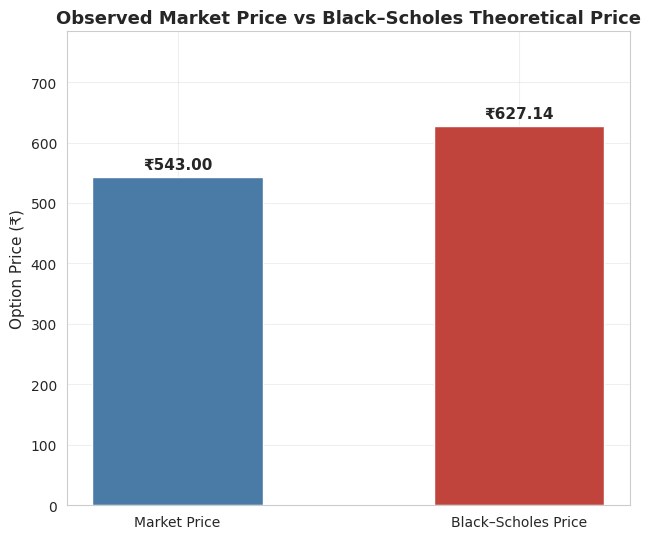

In [27]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
labels = ['Market Price', 'Black–Scholes Price']
values = [market_price, C_BS]
bars = ax.bar(labels, values, color=['#4a7ba6', '#c1443c'], width=0.5)

for bar, val in zip(bars, values):
    ax.annotate(f'₹{val:,.2f}', xy=(bar.get_x() + bar.get_width()/2, val),
                xytext=(0, 6), textcoords='offset points', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Observed Market Price vs Black–Scholes Theoretical Price')
ax.set_ylabel('Option Price (₹)')
ax.set_ylim(0, max(values) * 1.25)
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
plt.show()


**Interpretation:** The model produces a higher value than the observed market price for this particular option-date observation. This difference should **not** automatically be interpreted as model failure. It may arise from differences between the model's assumptions and actual market conditions, including volatility dynamics, dividends, liquidity, transaction costs, market risk premia, and — importantly — the specific choice of volatility input used to feed the model. This last point motivates the implied-volatility exercise in the next section.


## Part 17 — Implied Volatility

Historical volatility (Part 9) was estimated purely from *past* NIFTY returns. An alternative approach is to ask: what volatility, when plugged into the Black–Scholes formula, would make the *model* price exactly equal the *observed market* price? This is the **implied volatility**, obtained by solving

$$C_{BS}(\sigma) = C_{\text{market}}$$

for $\sigma$, using a numerical root-finder (Brent's method).


In [28]:
def bs_price_minus_market(sigma_candidate):
    return bs_call_price(S, K, T, r, q, sigma_candidate) - market_price

implied_vol = brentq(bs_price_minus_market, 0.0001, 3.0)

print(f"Implied volatility: {implied_vol:.6f}  ({implied_vol*100:.4f}%)")

# Verification: substitute implied volatility back into Black-Scholes
C_check = bs_call_price(S, K, T, r, q, implied_vol)
print(f"\nVerification -- Black-Scholes price using implied volatility: {C_check:,.4f}")
print(f"Observed market price:                                        {market_price:,.4f}")
print(f"(These should match to numerical precision.)")


Implied volatility: 0.111606  (11.1606%)

Verification -- Black-Scholes price using implied volatility: 543.0000
Observed market price:                                        543.0000
(These should match to numerical precision.)


In [29]:
vol_compare = pd.DataFrame({
    'Quantity': ['Historical volatility (from NIFTY returns)', 'Implied volatility (from market option price)'],
    'Value': [f'{sigma_annual*100:.4f}%', f'{implied_vol*100:.4f}%']
})
vol_compare


,Quantity,Value
0,Historical volatility (from NIFTY returns),13.4297%
1,Implied volatility (from market option price),11.1606%


## Part 18 — Historical vs Implied Volatility Graph

**Graph 7: Historical Volatility vs Implied Volatility**


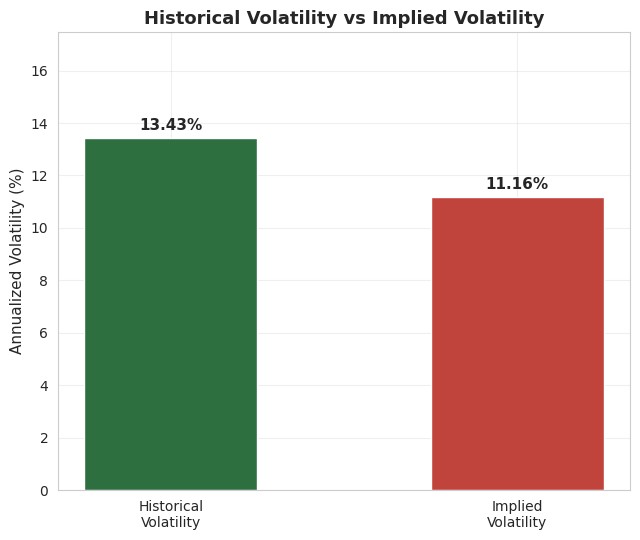

In [30]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
labels = ['Historical\nVolatility', 'Implied\nVolatility']
values = [sigma_annual * 100, implied_vol * 100]
bars = ax.bar(labels, values, color=['#2e6f40', '#c1443c'], width=0.5)

for bar, val in zip(bars, values):
    ax.annotate(f'{val:.2f}%', xy=(bar.get_x() + bar.get_width()/2, val),
                xytext=(0, 6), textcoords='offset points', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Historical Volatility vs Implied Volatility')
ax.set_ylabel('Annualized Volatility (%)')
ax.set_ylim(0, max(values) * 1.3)
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
plt.show()


**Interpretation:** Historical volatility summarizes the *realized* variability in past NIFTY return data — it is a purely statistical, backward-looking estimate. Implied volatility, by contrast, is the volatility parameter that makes the Black–Scholes model reproduce the *observed* option price — it is a market-derived, model-dependent quantity. **The two quantities therefore answer different questions**: one describes historical statistical behaviour, the other reflects what the market is currently pricing into the option, given the Black–Scholes framework. Implied volatility should be read as *the volatility consistent with the observed price under this model*, and **not** as a direct forecast of future realized volatility.


## Part 19 — Sensitivity: Call Price as a Function of Volatility

**Graph 8: Black–Scholes Call Price as a Function of Volatility**

$S$, $K$, $r$, $q$ and $T$ are held fixed at their values above; only $\sigma$ is varied.


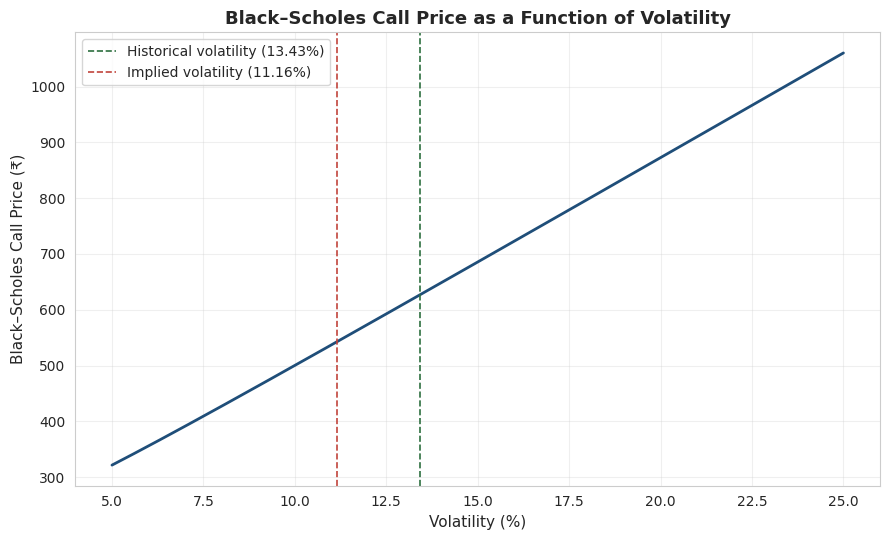

In [31]:
sigma_range = np.linspace(0.05, 0.25, 200)
prices_over_sigma = [bs_call_price(S, K, T, r, q, s) for s in sigma_range]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(sigma_range * 100, prices_over_sigma, color='#1f4e79', linewidth=2)

ax.axvline(sigma_annual * 100, color='#2e6f40', linestyle='--', linewidth=1.2,
           label=f'Historical volatility ({sigma_annual*100:.2f}%)')
ax.axvline(implied_vol * 100, color='#c1443c', linestyle='--', linewidth=1.2,
           label=f'Implied volatility ({implied_vol*100:.2f}%)')

ax.set_title('Black–Scholes Call Price as a Function of Volatility')
ax.set_xlabel('Volatility (%)')
ax.set_ylabel('Black–Scholes Call Price (₹)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


**Interpretation:** All else equal, the call price rises monotonically as volatility increases. A higher volatility increases the theoretical value of a European call because greater uncertainty widens the range of possible favourable outcomes for the holder, without creating a symmetric downside obligation — the most the call holder can lose is the premium paid, while the potential upside is unbounded. The historical and implied volatility markers fall in different positions along this curve, visually reinforcing the distinction drawn in Part 18.


## Part 20 — Assumptions Check


In [32]:
assumptions_table = pd.DataFrame({
    'Black-Scholes assumption': [
        'Continuous trading',
        'No transaction costs',
        'Constant risk-free rate',
        'Constant volatility',
        'Lognormal price process',
        'Known, fixed maturity',
        'European exercise (only at expiry)',
        'No arbitrage',
        'Dividend treatment'
    ],
    'Evidence / treatment in this analysis': [
        'Not directly testable from daily closing data',
        'Not modelled; observed market price implicitly reflects real-world frictions',
        'Assumed constant (r = 6.5%) over the option life; not estimated from data',
        'Rolling-volatility graph (Part 10) shows time variation in realized volatility',
        'Partially assessed via log-return histogram, Q-Q plot and Jarque-Bera test (Parts 7-8)',
        'Satisfied by construction: T computed directly from option and expiry dates',
        'Assumed, consistent with NIFTY index options being European-style',
        'Not directly testable with a single option observation',
        'Assumed q = 0 (no dividend adjustment); simplification for an index'
    ],
    'Comment': [
        'Assumed',
        'Assumed / Potential limitation',
        'Assumed',
        'Potential limitation',
        'Approximately satisfied / Potential limitation',
        'Approximately satisfied',
        'Assumed',
        'Not directly testable',
        'Potential limitation'
    ]
})
assumptions_table


,Black-Scholes assumption,Evidence / treatment in this analysis,Comment
0,Continuous trading,Not directly testable from daily closing data,Assumed
1,No transaction costs,Not modelled; observed market price implicitly...,Assumed / Potential limitation
2,Constant risk-free rate,Assumed constant (r = 6.5%) over the option li...,Assumed
3,Constant volatility,Rolling-volatility graph (Part 10) shows time ...,Potential limitation
4,Lognormal price process,"Partially assessed via log-return histogram, Q...",Approximately satisfied / Potential limitation
5,"Known, fixed maturity",Satisfied by construction: T computed directly...,Approximately satisfied
6,European exercise (only at expiry),"Assumed, consistent with NIFTY index options b...",Assumed
7,No arbitrage,Not directly testable with a single option obs...,Not directly testable
8,Dividend treatment,Assumed q = 0 (no dividend adjustment); simpli...,Potential limitation


**Important:** this table classifies each assumption based on available empirical diagnostics; it does not claim that every assumption has been statistically *proven*. The empirical diagnostics assess what can be assessed from the data at hand — the Black–Scholes model itself remains a theoretical framework built on idealized conditions.


## Part 21 — Model Limitations

1. **Constant volatility assumption.** Black–Scholes treats $\sigma$ as fixed over the option's life, but Part 10 showed that realized volatility varies through time.
2. **Historical volatility may differ from future volatility.** The volatility used as an input is backward-looking; the market's own implied volatility (11–13% region here) need not coincide with it, and neither is guaranteed to match volatility actually realized between now and expiry.
3. **Return distributions may exhibit heavy tails.** The positive excess kurtosis observed in Part 7 suggests that extreme moves are more frequent than a normal-return model would predict.
4. **Market prices include liquidity and risk-premium effects.** The observed option price reflects not just a statistical volatility estimate but supply, demand, liquidity conditions, and any volatility risk premium embedded in option markets.
5. **Interest rate and dividend assumptions affect valuation.** The risk-free rate (6.5%) and zero-dividend assumption are simplifications rather than values estimated from data specific to this option.
6. **Market microstructure effects.** Bid–ask spreads and other trading-mechanics factors affect the single observed closing price used here, which the model does not represent.
7. **Single-observation caveat.** The option dataset provides exactly one market observation (31-Aug-2026 close for the 24100 CE contract); this is not a comprehensive statistical validation exercise.

**This analysis is an empirical illustration of the model rather than a comprehensive statistical validation.**


## Part 22 — Final Summary Table


In [33]:
summary_table = pd.DataFrame({
    'Stage': [
        'NIFTY observations used',
        'Log-return observations',
        'Daily volatility',
        'Annualized historical volatility',
        'Spot price',
        'Strike',
        'Time to expiry',
        'Risk-free rate',
        'Black-Scholes price',
        'Observed market price',
        'Difference',
        'Implied volatility'
    ],
    'Result': [
        f'{n_prices}',
        f'{n_returns}',
        f'≈{sigma_daily*100:.3f}%',
        f'≈{sigma_annual*100:.2f}%',
        f'₹{S:,.2f}',
        f'₹{K:,.2f}',
        f'{T_days} days ({T:.5f} yrs)',
        f'{r*100:.1f}% (assumed)',
        f'≈₹{C_BS:,.2f}',
        f'₹{market_price:,.2f}',
        f'≈₹{abs_diff:,.2f}',
        f'≈{implied_vol*100:.2f}%'
    ]
})
summary_table


,Stage,Result
0,NIFTY observations used,241
1,Log-return observations,240
2,Daily volatility,≈0.846%
3,Annualized historical volatility,≈13.43%
4,Spot price,"₹24,080.40"
5,Strike,"₹24,100.00"
6,Time to expiry,57 days (0.15616 yrs)
7,Risk-free rate,6.5% (assumed)
8,Black-Scholes price,≈₹627.14
9,Observed market price,₹543.00


## How I Would Close the Seminar

*(A 30–45 second spoken conclusion.)*

"To bring this together: we started with a theoretical, statistically-motivated model — Black–Scholes — and brought it face-to-face with actual NIFTY 50 data. Using roughly the past year of daily NIFTY returns, we estimated a historical volatility of around 13%, and used it to compute a Black–Scholes value of around ₹627 for a NIFTY call option that actually traded that day at ₹543. Reversing the model to match the market price exactly gave us an implied volatility of around 11%. The gap between these two volatility numbers is the real takeaway: Black–Scholes is therefore not merely a formula for producing a price; it provides a framework for relating observed market prices to uncertainty, and to the assumptions used to model that uncertainty. (The exact figures computed above should be quoted live from the notebook's output.)"


## Validation Checks

The following assertions confirm that the key computed quantities fall within tolerance of the expected seminar magnitudes (tolerances are used for calculated/estimated values; exact equality is used only for values read directly off the raw data).


In [34]:
checks = []

def check(name, condition, detail):
    status = 'PASS' if condition else 'FAIL'
    checks.append((name, status, detail))
    print(f"[{status}] {name}: {detail}")

check('S == 24080.40', np.isclose(S, 24080.40), f'S = {S}')
check('K == 24100', np.isclose(K, 24100), f'K = {K}')
check('market_price == 543', np.isclose(market_price, 543.00), f'market_price = {market_price}')
check('n_prices == 241', n_prices == 241, f'n_prices = {n_prices}')
check('n_returns == 240', n_returns == 240, f'n_returns = {n_returns}')
check('T_days == 57', T_days == 57, f'T_days = {T_days}')
check('historical_volatility ~ 0.1343 (tol 0.01)', abs(sigma_annual - 0.1343) < 0.01, f'sigma_annual = {sigma_annual:.6f}')
check('BS_price ~ 627.14 (tol 15)', abs(C_BS - 627.14) < 15, f'C_BS = {C_BS:.4f}')
check('implied_volatility ~ 0.1116 (tol 0.01)', abs(implied_vol - 0.1116) < 0.01, f'implied_vol = {implied_vol:.6f}')

print("\nAll checks use the ACTUAL values computed from the uploaded CSV files above; the reference figures are seminar-plan sanity checks, not hard-coded results.")


[PASS] S == 24080.40: S = 24080.4
[PASS] K == 24100: K = 24100.0
[PASS] market_price == 543: market_price = 543.0
[PASS] n_prices == 241: n_prices = 241
[PASS] n_returns == 240: n_returns = 240
[PASS] T_days == 57: T_days = 57
[PASS] historical_volatility ~ 0.1343 (tol 0.01): sigma_annual = 0.134297
[PASS] BS_price ~ 627.14 (tol 15): C_BS = 627.1377
[PASS] implied_volatility ~ 0.1116 (tol 0.01): implied_vol = 0.111606

All checks use the ACTUAL values computed from the uploaded CSV files above; the reference figures are seminar-plan sanity checks, not hard-coded results.
